# EDA 
1. Are the labels meaningful?
2. Is there class imbalance?
3. Which features have real signal?
4. Are outliers errors or reality?

## Importing libraries

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

In [2]:
# Loading model tables
df = pd.read_csv("../outputs/model_table.csv")
df.shape

(25000, 20)

In [3]:
# convert data columns
df['registration_date'] = pd.to_datetime(df['registration_date'],errors='coerce')
df['visit_date'] = pd.to_datetime(df['visit_date'],errors='coerce')
df['billing_date'] = pd.to_datetime(df['billing_date'],errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   patient_id            25000 non-null  int64         
 1   age                   25000 non-null  int64         
 2   gender                25000 non-null  str           
 3   city                  25000 non-null  str           
 4   insurance_provider    25000 non-null  str           
 5   chronic_flag          25000 non-null  int64         
 6   registration_date     25000 non-null  datetime64[us]
 7   visit_id              25000 non-null  int64         
 8   visit_date            25000 non-null  datetime64[us]
 9   department            25000 non-null  str           
 10  visit_type            25000 non-null  str           
 11  length_of_stay_hours  25000 non-null  float64       
 12  risk_score            25000 non-null  str           
 13  doctor_id             25000

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
patient_id,25000.0,NaN,NaN,NaN,2509.51536,1.0,1249.0,2505.0,3764.0,5000.0,1448.68904
age,25000.0,NaN,NaN,NaN,44.76832,1.0,33.0,45.0,57.0,90.0,17.784232
gender,25000,2,F,12739,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,25000,6,Hyderabad,4370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance_provider,25000,4,MediCareX,6532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chronic_flag,25000.0,NaN,NaN,NaN,0.5026,0.0,0.0,1.0,1.0,1.0,0.500003
registration_date,25000,NaN,NaN,NaN,2025-07-18 16:17:11.040000,2025-01-20 00:00:00,2025-04-16 00:00:00,2025-07-19 00:00:00,2025-10-19 00:00:00,2026-01-20 00:00:00,NaN
visit_id,25000.0,NaN,NaN,NaN,12500.5,1.0,6250.75,12500.5,18750.25,25000.0,7217.022701
visit_date,25000,NaN,NaN,NaN,2025-07-21 15:25:51.744000,2025-01-20 00:00:00,2025-04-21 00:00:00,2025-07-21 00:00:00,2025-10-21 00:00:00,2026-01-20 00:00:00,NaN
department,25000,6,General,4228,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Distribution Analysis
## Missing Values Analysis
First thing we always check : What is missing and why

Not all nulls are data errors some are business logic 

In [5]:
# overall null check
df.isnull().sum().sort_values(ascending=False)

approved_amount         1318
payment_days             790
patient_id                 0
age                        0
city                       0
gender                     0
insurance_provider         0
chronic_flag               0
visit_date                 0
department                 0
registration_date          0
visit_id                   0
length_of_stay_hours       0
visit_type                 0
risk_score                 0
doctor_id                  0
billed_amount              0
bill_id                    0
claim_status               0
billing_date               0
dtype: int64

In [6]:
# Focus on key columns
df[['approved_amount','payment_days','length_of_stay_hours']].isnull().sum()

approved_amount         1318
payment_days             790
length_of_stay_hours       0
dtype: int64

## Step 2 - Business Logic Validation

In [7]:
# check A- Paid claims should always have an approved ampunt
# if this returns 0 we are clean
df[
    (df['claim_status'] == 'Paid') &
    (df['approved_amount'].isna())
].shape

(817, 20)

In [8]:
# Check B - payment days missing breakdown by claim status
df[df['payment_days'].isna()]['claim_status'].value_counts()

claim_status
Paid        459
Pending     208
Rejected    123
Name: count, dtype: int64

for pending and rejected claim statuses we can expect the payment days to be null, hoewever for Paid claim status it should not be null and should have a value

In [9]:
# Check C - LOS should never be negative
(df['length_of_stay_hours']<0).sum()

np.int64(0)

## Step 3 - Distribution Analysis

In [11]:
# categorical column reports
print("========== Department ============")
print(df['department'].value_counts())
print("\n============ Visit type=========")
print(df['visit_type'].value_counts())
print("\n============ Insurance Provider============")
print(df['insurance_provider'].value_counts())
print("\n============City==================")
print(df['city'].value_counts())

========== Department ============
department
General        4228
ER             4220
Neurology      4165
Orthopedics    4164
Cardiology     4159
ICU            4064
Name: count, dtype: int64

============ Visit type=========
visit_type
ER     8382
OPD    8381
ICU    8237
Name: count, dtype: int64

============ Insurance Provider============
insurance_provider
MediCareX     6532
CareOne       6283
HealthPlus    6220
SecureLife    5965
Name: count, dtype: int64

============City==================
city
Hyderabad    4370
Pune         4221
Bangalore    4205
Mumbai       4122
Delhi        4107
Chennai      3975
Name: count, dtype: int64


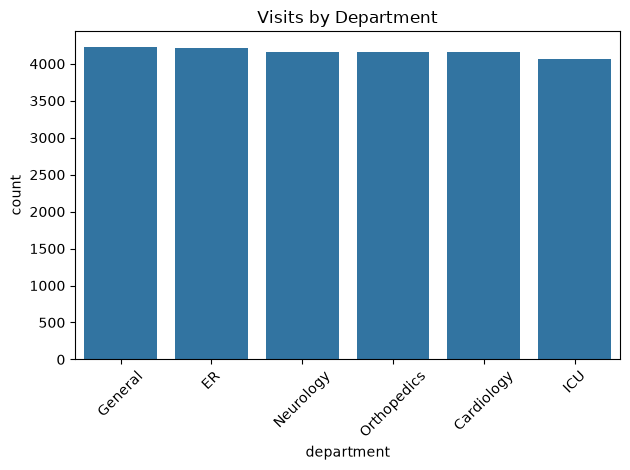

In [14]:
# bar chart showing visits by department
sns.countplot(data=df,x='department',order=df['department'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by Department")
plt.tight_layout()
plt.show()

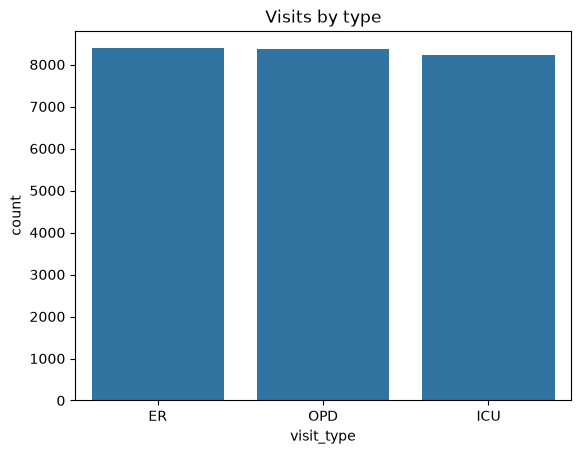

In [16]:
# visits by type
sns.countplot(data=df,x="visit_type",order=df['visit_type'].value_counts().index)
plt.title("Visits by type")
plt.show()

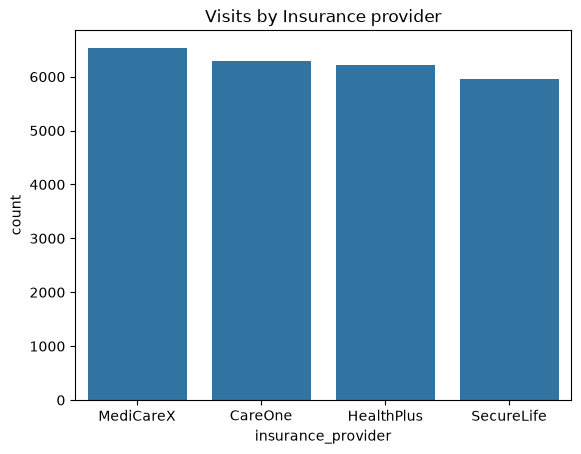

In [17]:
# visits by Insurance provider
sns.countplot(data=df,x="insurance_provider",order=df['insurance_provider'].value_counts().index)
plt.title("Visits by Insurance provider")
plt.show()

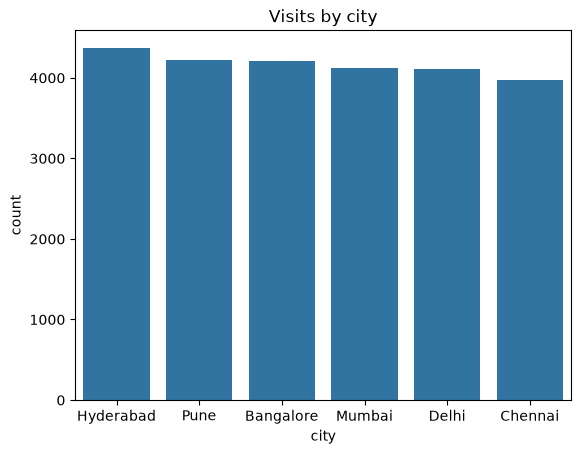

In [18]:
# Visits by City
sns.countplot(data=df,x="city",order=df['city'].value_counts().index)
plt.title("Visits by city")
plt.show()

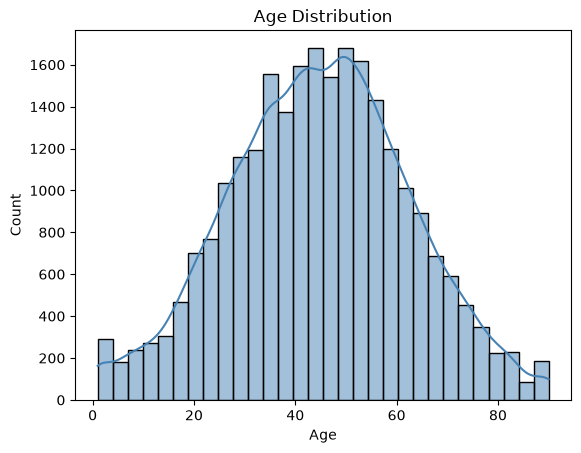

count    25000.00
mean        44.77
std         17.78
min          1.00
25%         33.00
50%         45.00
75%         57.00
max         90.00
Name: age, dtype: float64


In [20]:
# Age distribution
sns.histplot(df['age'],bins=30,kde=True,color='steelblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()
print(df['age'].describe().round(2))

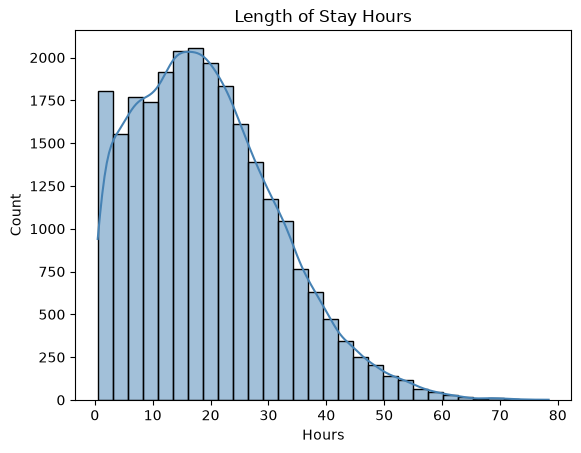

count    25000.00
mean        19.55
std         12.31
min          0.50
25%          9.96
50%         18.20
75%         27.31
max         78.42
Name: length_of_stay_hours, dtype: float64


In [21]:
# Length of stay distribution
sns.histplot(df['length_of_stay_hours'],bins=30,kde=True,color='steelblue')
plt.title("Length of Stay Hours")
plt.xlabel("Hours")
plt.show()
print(df['length_of_stay_hours'].describe().round(2))

most patients stay for shorter hours we can see that most of them are clustered in the 0-30 hours. We have a right skew in this case

In [22]:
# IQR for LOS
# 25% = 9.96 (bottom quarter boundary)
# 75% = 27.31 (top quarter boundary)
IQR = 27.31 - 9.96
print(IQR)

17.349999999999998


In [23]:
# Upper Fence
# An upper fence is bthe cutoff beyond which a value is considered to be am outlier
#upper_fence = 75% + (1.5*IQR)
upper_fence = 27.31 + (1.5*17.35)
print(upper_fence)

53.335


## Outlier Detection
**Two approaches:**
- Boxplot - visual detection
- IQR method - numerical calculation


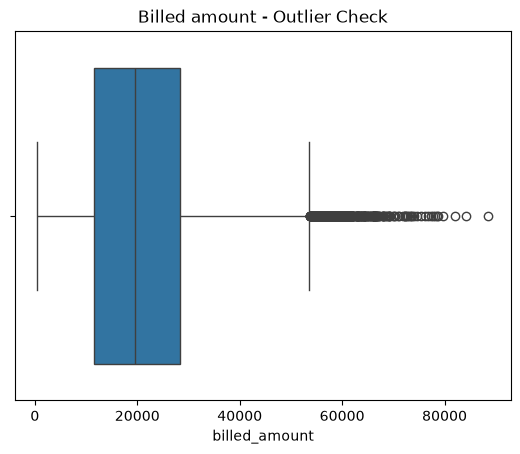

In [24]:
sns.boxplot(x=df['billed_amount'])
plt.title("Billed amount - Outlier Check")
plt.show()

Beyond approximately 55000 bills is what we consider outliers with a few whiskers that reach even above 80000 (possibly for longer surgeries and complex medical procidures)

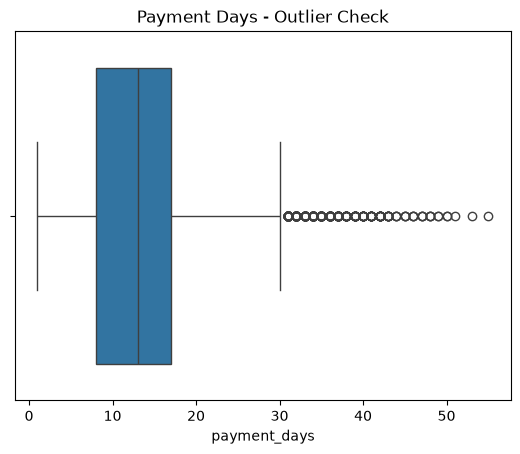

In [25]:
sns.boxplot(x=df['payment_days'])
plt.title("Payment Days - Outlier Check")
plt.show()

Most bills are payed within 17 days. The dots crossing past 30 and stretching towards around 55 are the outlier payments (insurers that take over a month to pay)

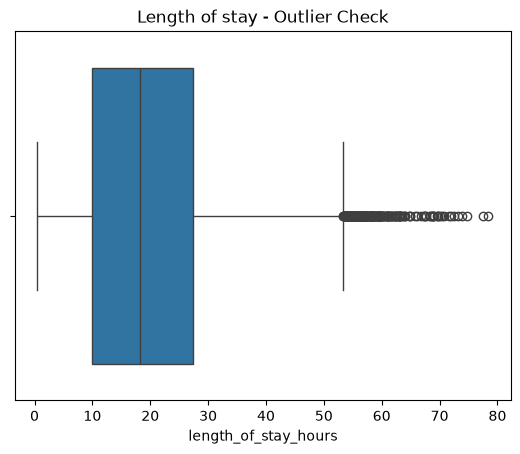

In [26]:
sns.boxplot(x=df['length_of_stay_hours'])
plt.title("Length of stay - Outlier Check")
plt.show()

similar to payment days and billed amount this box plot also shows outliers in the right tail. This chart also matches the previously calculated upper fence where outliers are in the values above the upper fence

In [27]:
# IQR explicit calculation - numbers behind box plot
for col in ['length_of_stay_hours','billed_amount','payment_days']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    n_out = ((df[col] <lower) | (df[col] > upper)).sum()

    print(f"{col}")
    print(f"Q1 = {Q1:.1f} | Q3 = {Q3:.1f} | IQR = {IQR:.1f}")
    print(f"   Lower bound = {lower:.1f} | Upper bound = {upper:.1f}")
    print(f"  Outliers = {n_out} rows")
    print()


length_of_stay_hours
Q1 = 10.0 | Q3 = 27.3 | IQR = 17.4
   Lower bound = -16.1 | Upper bound = 53.3
  Outliers = 256 rows

billed_amount
Q1 = 11582.5 | Q3 = 28398.1 | IQR = 16815.6
   Lower bound = -13641.0 | Upper bound = 53621.5
  Outliers = 373 rows

payment_days
Q1 = 8.0 | Q3 = 17.0 | IQR = 9.0
   Lower bound = -5.5 | Upper bound = 30.5
  Outliers = 509 rows



## Feature Correlations 
**We encode the target variables numerically so we can measure correlation**
- risk_score -> Low=0, Meduim=1,High=2
- claim_status -> Paid=0,Pending=1,Rejected=2

In [28]:
# Encode target for correlation analysis
df['risk_numeric'] = df['risk_score'].map(
    {"Low:":0,"Meduim":1,"High":2}
)
df["claim_numeric"] = df['claim_status'].map(
    {"Paid":0,"Pending":1,"Rejected":2}
)
print("risk numeric :", {"Low:":0,"Meduim":1,"High":2})
print("claim numeric: ",{"Paid":0,"Pending":1,"Rejected":2})

risk numeric : {'Low:': 0, 'Meduim': 1, 'High': 2}
claim numeric:  {'Paid': 0, 'Pending': 1, 'Rejected': 2}


In [29]:
df['risk_numeric']

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
24995    2.0
24996    2.0
24997    2.0
24998    NaN
24999    NaN
Name: risk_numeric, Length: 25000, dtype: float64

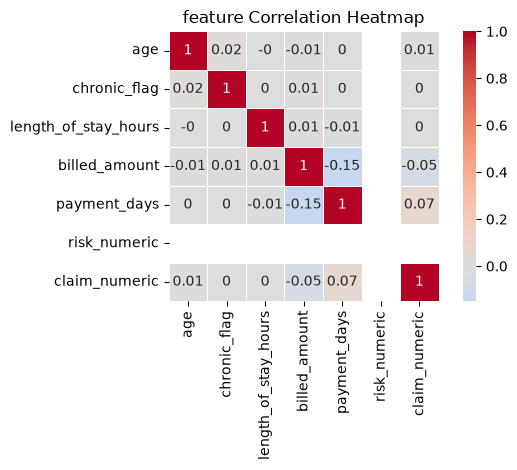

In [31]:
# full correlation heatmap
numerical_cols = [
    "age",
    "chronic_flag",
    "length_of_stay_hours",
    "billed_amount",
    "payment_days",
    "risk_numeric",
    "claim_numeric"
]
corr = df[numerical_cols].corr().round(2)
sns.heatmap(corr,annot=True,cmap="coolwarm",center=0,linewidth=0.5,square=True)
plt.title("feature Correlation Heatmap")
plt.tight_layout()
plt.show()

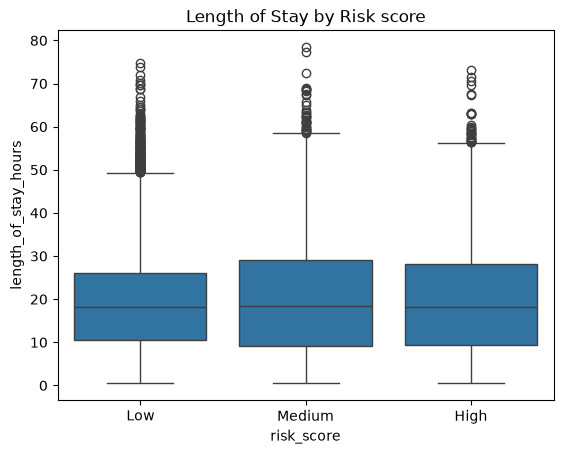


 Mean LOS by Risk Score:
risk_score
High      19.76
Low       19.15
Medium    20.08
Name: length_of_stay_hours, dtype: float64


In [32]:
# LOS by risk score
sns.boxplot(data=df,x="risk_score",y="length_of_stay_hours",order=['Low','Medium','High'])
plt.title("Length of Stay by Risk score")
plt.show()

print("\n Mean LOS by Risk Score:")
print(df.groupby("risk_score")['length_of_stay_hours'].mean().round(2))

Rejection Rate by Insurance Provider (%):
insurance_provider
SecureLife    15.7
MediCareX     15.2
HealthPlus    15.0
CareOne       14.9
Name: is_rejected, dtype: float64


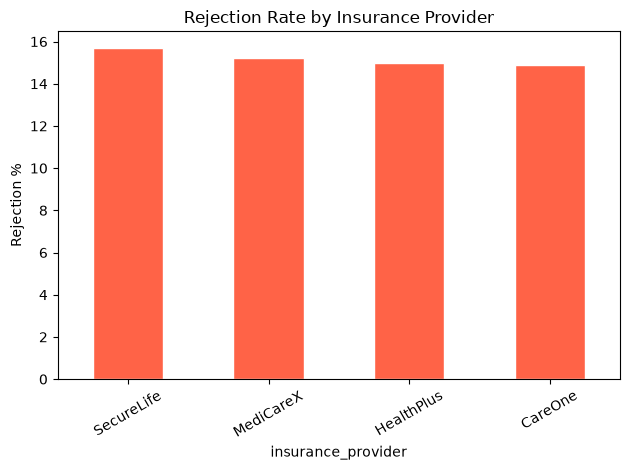

In [35]:
# Rejection by insurance provider
df['is_rejected'] = (df['claim_status'] == "Rejected").astype(int)

rej_rate = (df.groupby("insurance_provider")["is_rejected"].mean()
            .sort_values(ascending=False)
            .mul(100)
            .round(1))

print("Rejection Rate by Insurance Provider (%):")
print(rej_rate)

rej_rate.plot(kind="bar",color="tomato",edgecolor="white")
plt.title("Rejection Rate by Insurance Provider")
plt.ylabel("Rejection %")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Class Imbalance Deep Dive
**Class Imbalance**
- Class Imbalance
- Class collapse

In [ ]:
# Naive baseline - what happens if we always predict the majority class

most_common = df['risk_score'].mode()[0]
naive_acc = (df['risk_score'] == most_common).mean()
print(f"Majority class: {most_common}")
print(f"Naive Accuracy : {naive_acc:.1%}")

Majority class: Low
Naive Accuracy : 49.9%


In [43]:
# Demo setup - 2 features only, to keep it clean
X_demo = df[['length_of_stay_hours','chronic_flag']].fillna(0)
y_demo = df["risk_score"]

# without class weight
model_bad = LogisticRegression(max_iter=1000,random_state=42)
model_bad.fit(X_demo,y_demo)
pred_bad = model_bad.predict(X_demo)
print("Without class weight = 'balanced'")
print("-"*45)
print(classification_report(y_demo,pred_bad))

# model trained with class weights = balanced
model_good = LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced')
model_good.fit(X_demo,y_demo)
pred_good = model_good.predict(X_demo)
print("With class weight = 'balanced'")
print("-"*45)
print(classification_report(y_demo,pred_good))

Without class weight = 'balanced'
---------------------------------------------
              precision    recall  f1-score   support

        High       0.00      0.00      0.00      5034
         Low       0.50      1.00      0.67     12470
      Medium       0.00      0.00      0.00      7496

    accuracy                           0.50     25000
   macro avg       0.17      0.33      0.22     25000
weighted avg       0.25      0.50      0.33     25000

With class weight = 'balanced'
---------------------------------------------
              precision    recall  f1-score   support

        High       0.19      0.20      0.20      5034
         Low       0.50      0.46      0.48     12470
      Medium       0.32      0.35      0.34      7496

    accuracy                           0.37     25000
   macro avg       0.34      0.34      0.34     25000
weighted avg       0.38      0.37      0.38     25000

